In [119]:
!pip install pyNutriScore

In [1]:
# Defining Nutriscore

from pyNutriScore import NutriScore
from pyNutriScore import NutriScore
import pandas as pd

def nutriscore(row):
    #Retrieve values for each nutritional component 
    
    energy = row['cal']
    
        
    fibers = (row['g_fiber']/energy)*100
    fruit_percentage = 0
    proteins = (row['g_protein']/energy)*100
    saturated_fats = (row['g_sat_fat']/energy)*100
    sodium = (row['mg_sodium']/energy)*100
    sugar = (row['g_sugar']/energy)*100

    result = NutriScore().calculate(
         {
        'energy': 100,
        'fibers': fibers,
        'fruit_percentage': fruit_percentage,
        'proteins': proteins,
        'saturated_fats': saturated_fats,
        'sodium': sodium,
        'sugar': sugar,
    },
    'solid'  # either 'solid' or 'beverage'
)
    
    return result



In [2]:
# making a nutriscore column in df

school_menus_df = pd.read_csv('School_Menus.csv')

df = school_menus_df
df = df[df['category'] == "entree"]
df = df.dropna(subset=['cal'])
df = df[df['cal'] != 0]


df['nutriscore_entree'] = df.apply(nutriscore, axis=1)



average_entree_nutriscore=pd.DataFrame(df.groupby(['school_name'])['nutriscore_entree'].mean())


number_unique_entree_df=pd.DataFrame(df.groupby(['school_name'])['food_name'].nunique())


merged_df = pd.merge(average_entree_nutriscore, number_unique_entree_df, on='school_name')


/var/folders/hh/1ddz0cz536sb8pznv3jdpz180000gn/T/ipykernel_69721/2803171311.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  school_menus_df = pd.read_csv('School_Menus.csv')


In [3]:
#making a nutriscore category for vegetable fruit and entree
#counting unique fruit and unique vegetable as variable


df = school_menus_df
df = df[df['category'].isin(["vegetable","fruit", "entree"])]
df = df.dropna(subset=['cal'])
df = df[df['cal'] != 0]


df['nutriscore_vef'] = df.apply(nutriscore, axis=1)



average_vef_nutriscore=pd.DataFrame(df.groupby(['school_name'])['nutriscore_vef'].mean())


merged_df = pd.merge(merged_df, average_vef_nutriscore, on='school_name')


fruit_df = school_menus_df[school_menus_df['category'] == "fruit"]
number_unique_fruit_df=pd.DataFrame(fruit_df.groupby(['school_name'])['food_name'].nunique())
merged_df = merged_df[merged_df.index.isin(number_unique_fruit_df.index)]
merged_df = pd.merge( number_unique_fruit_df, merged_df, on='school_name')
merged_df = merged_df.rename(columns={'food_name_x': 'unique_fruit', 'food_name_y': 'unique_entree'})



veg_df = school_menus_df[school_menus_df['category'] == "vegetable"]

number_unique_veg_df=pd.DataFrame(veg_df.groupby(['school_name'])['food_name'].nunique())

merged_df = merged_df[merged_df.index.isin(number_unique_veg_df.index)]
merged_df = pd.merge( number_unique_veg_df, merged_df, on='school_name')
merged_df = merged_df.rename(columns={'food_name': 'unique_veg'})
merged_df.to_csv('schools_with_data.csv')

In [4]:
schools = pd.read_csv('schools_with_data.csv')

In [5]:
schools

,school_name,unique_veg,unique_fruit,nutriscore_entree,unique_entree,nutriscore_vef
0,Bishop Guilfoyle Catholic High School - PA,20,10,-1.105263,18,-0.513158
1,Beaver Area High - Beaver Area School District...,22,11,-1.350340,48,-0.838983
2,Beaver Area Middle - Beaver Area School Distri...,22,11,-1.390244,48,-0.860399
3,Bedford Area High School - Bedford Area School...,16,13,-1.794118,33,-0.887640
4,Bedford Area Middle School - Bedford Area Scho...,16,11,-1.618182,36,-0.785714
...,...,...,...,...,...,...
87,Windber Area High School - Windber Area School...,4,3,-1.137931,29,-1.324324
88,Wissahickon High - Wissahickon School District...,14,12,-1.448819,73,-1.087719
89,Wissahickon Middle - Wissahickon School Distri...,14,12,-1.448819,73,-1.087719
90,Yough High School - Yough School District - PA,19,14,-1.257143,48,-0.872340


In [6]:
schools['district'] = schools['school_name'].str.split("-").str[1].str.split(" School District").str[0] 

In [7]:
#Removing first row since it is a private school 

schools = schools.iloc[1:]

In [8]:
# Adding district name to df

import pandas as pd
income_df = pd.read_csv('income.csv')

income_df['School District'] = income_df['School District'].str.replace(' SD', '', regex=False)
income_df['School District'] = income_df['School District'].str.rstrip()
income_df['School District'] = income_df['School District'].str.lstrip()
income_df = income_df.rename(columns={'School District': 'district'})


schools['district'] = schools['district'].str.rstrip()
schools['district'] = schools['district'].str.lstrip()


districts = list(schools['district'])


new_districts = []
for district in districts:
    if district == 'Antis High School' or district == 'Antis Middle School':
        district = 'Bellwood-Antis'
    elif district == 'Cameron County SD':
        district = 'Cameron County'
    elif district == 'Hempfield SD (PA)':
        district = 'Hempfield'
    elif district == 'Highspire Jr. Sr. High School':
        district = 'Steelton-Highspire'
    elif district == 'PA':
        district = 'Northwestern Lehigh'
    elif district == 'North Cambria':
        district = 'Northern Cambria'
    elif district == 'Richland High School' or district == 'Richland Middle School':
        district = 'Richland'
    elif district == 'Shikellamy Area':
        district = 'Shikellamy'
    elif district == 'Barre Area High School':
        district = 'Wilkes-Barre Area'

    new_districts.append(district)


schools['district']=new_districts



/var/folders/hh/1ddz0cz536sb8pznv3jdpz180000gn/T/ipykernel_69721/1724381495.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  schools['district'] = schools['district'].str.rstrip()
/var/folders/hh/1ddz0cz536sb8pznv3jdpz180000gn/T/ipykernel_69721/1724381495.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  schools['district'] = schools['district'].str.lstrip()
/var/folders/hh/1ddz0cz536sb8pznv3jdpz180000gn/T/ipykernel_69721/1724381495.py:41: SettingWithCopyWarning: 
A value is trying to be set on a cop

In [9]:
#adding income column to df

schools =pd.merge( schools, income_df, on='district')

In [10]:
schools

,school_name,unique_veg,unique_fruit,nutriscore_entree,unique_entree,nutriscore_vef,district,AUN,County,Records,Compensation,Net Profits,Dividends & Interest,Miscellaneous Income,Out-of-State Tax Records,Out-of-State Tax Credit,Out-of-State Income (calculated),Total\nPersonal\nIncome,Adjusted\nPersonal\nIncome\nJune 2025
0,Beaver Area High - Beaver Area School District...,22,11,-1.350340,48,-0.838983,Beaver Area,127041203.0,Beaver,"7,376","$486,152,067","$50,287,088","$27,127,774","$41,990,150",81,"$115,896","$3,775,114","$605,557,079","$601,781,965"
1,Beaver Area Middle - Beaver Area School Distri...,22,11,-1.390244,48,-0.860399,Beaver Area,127041203.0,Beaver,"7,376","$486,152,067","$50,287,088","$27,127,774","$41,990,150",81,"$115,896","$3,775,114","$605,557,079","$601,781,965"
2,Bedford Area High School - Bedford Area School...,16,13,-1.794118,33,-0.887640,Bedford Area,108051003.0,Bedford,"7,695","$354,820,804","$68,876,887","$19,709,017","$29,072,116",100,"$305,633","$9,955,472","$472,478,824","$462,523,352"
3,Bedford Area Middle School - Bedford Area Scho...,16,11,-1.618182,36,-0.785714,Bedford Area,108051003.0,Bedford,"7,695","$354,820,804","$68,876,887","$19,709,017","$29,072,116",100,"$305,633","$9,955,472","$472,478,824","$462,523,352"
4,Bellwood-Antis High School - Bellwood-Antis Sc...,18,14,-1.357143,28,-0.964706,Bellwood-Antis,108071003.0,Blair,"3,867","$204,069,256","$18,106,183","$9,254,479","$13,153,328",20,"$101,647","$3,310,977","$244,583,246","$241,272,269"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,Windber Area High School - Windber Area School...,4,3,-1.137931,29,-1.324324,Windber Area,108569103.0,Somerset,"4,014","$177,324,769","$8,506,479","$6,048,714","$5,381,105",22,"$24,021","$782,443","$197,261,067","$196,478,624"
87,Wissahickon High - Wissahickon School District...,14,12,-1.448819,73,-1.087719,Wissahickon,123469303.0,Montgomery,"20,203","$2,370,085,887","$580,769,054","$330,690,874","$431,256,420",870,"$3,651,345","$118,936,319","$3,712,802,235","$3,593,865,916"
88,Wissahickon Middle - Wissahickon School Distri...,14,12,-1.448819,73,-1.087719,Wissahickon,123469303.0,Montgomery,"20,203","$2,370,085,887","$580,769,054","$330,690,874","$431,256,420",870,"$3,651,345","$118,936,319","$3,712,802,235","$3,593,865,916"
89,Yough High School - Yough School District - PA,19,14,-1.257143,48,-0.872340,Yough,107658903.0,Westmoreland,"7,178","$359,956,053","$61,118,317","$13,068,788","$17,588,126",36,"$53,659","$1,747,850","$451,731,284","$449,983,434"


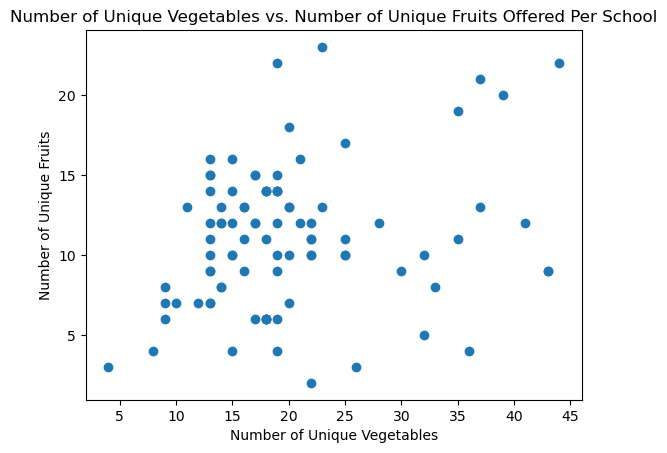

In [91]:
# mapping unique veg and unique fruit for each school
import matplotlib.pyplot as plt

# Data
x = schools['unique_veg']
y = schools['unique_fruit']

# Create plot
plt.scatter(x, y)

# Add descriptions
plt.title("Number of Unique Vegetables vs. Number of Unique Fruits Offered Per School")
plt.xlabel("Number of Unique Vegetables")
plt.ylabel("Number of Unique Fruits")

# Display
plt.show()

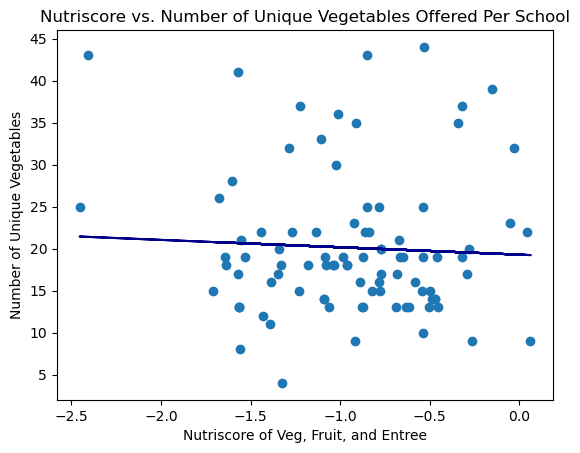

In [12]:

import matplotlib.pyplot as plt
import numpy as np
# Data
x = schools['nutriscore_vef']
y = schools['unique_veg']

# Create plot
plt.scatter(x, y)
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='darkblue', label=f'Best Fit: y={m:.2f}x+{b:.2f}')
# Add descriptions
plt.title("Nutriscore vs. Number of Unique Vegetables Offered Per School")
plt.xlabel("Nutriscore of Veg, Fruit, and Entree")
plt.ylabel("Number of Unique Vegetables")

# Display
plt.show()

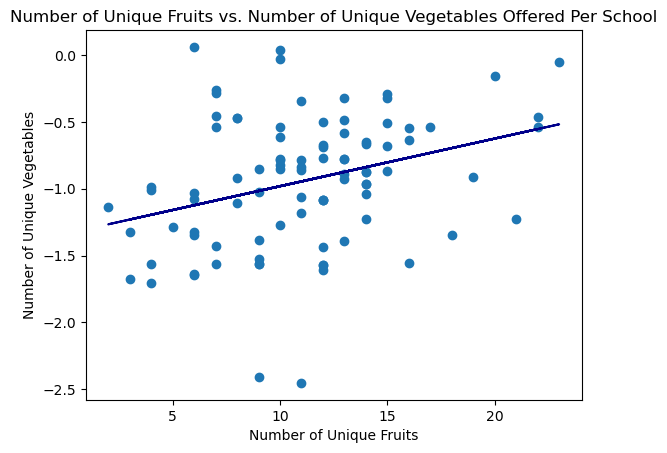

In [101]:
import matplotlib.pyplot as plt
import numpy as np
# Data
x = schools['unique_fruit']
y = schools['nutriscore_vef']

# Create plot
plt.scatter(x, y)
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='darkblue', label=f'Best Fit: y={m:.2f}x+{b:.2f}')
# Add descriptions
plt.title("Number of Unique Fruits vs. Number of Unique Vegetables Offered Per School")
plt.xlabel("Number of Unique Fruits")
plt.ylabel("Number of Unique Vegetables")

# Display
plt.show()

In [184]:
df_sorted = merged_df.sort_values(by='Adjusted\nPersonal\nIncome\nJune 2025').reset_index(drop=True)

In [225]:
# sorting by income incase analysis is done by income bracket

df_1 = df_sorted.iloc[:30,]
df_2 = df_sorted.iloc[:70, ]
df_3 = df_sorted.iloc[60:, ]

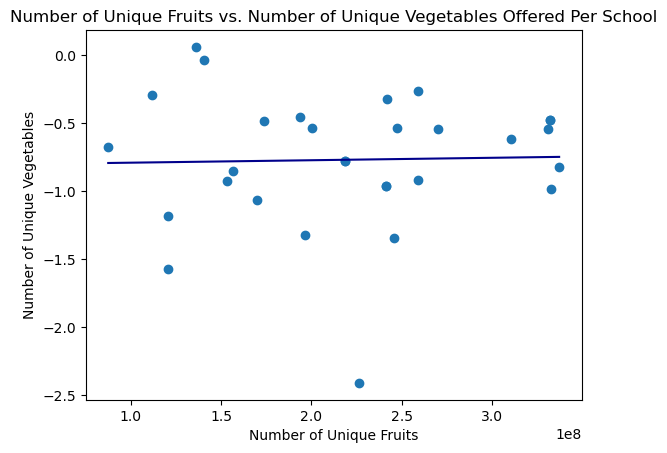

In [191]:
import matplotlib.pyplot as plt
import numpy as np
# Data
x = df_1['Adjusted\nPersonal\nIncome\nJune 2025']
y = df_1['nutriscore_vef']

# Create plot
plt.scatter(x, y)
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='darkblue', label=f'Best Fit: y={m:.2f}x+{b:.2f}')
# Add descriptions
plt.title("Number of Unique Fruits vs. Number of Unique Vegetables Offered Per School")
plt.xlabel("Number of Unique Fruits")
plt.ylabel("Number of Unique Vegetables")

# Display
plt.show()

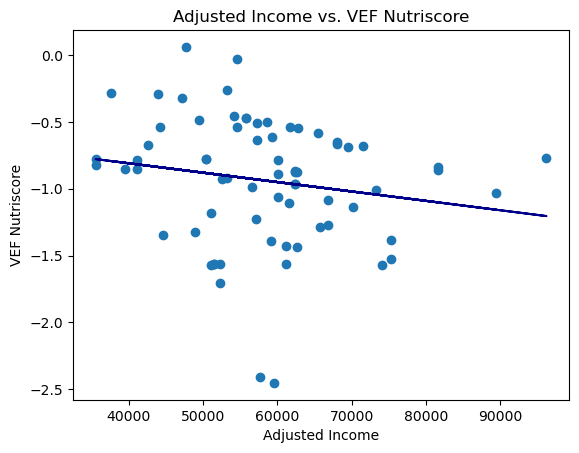

In [226]:
import matplotlib.pyplot as plt
import numpy as np
# Data
x = df_2['adjusted_income']
y = df_2['nutriscore_vef']

# Create plot
plt.scatter(x, y)
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='darkblue', label=f'Best Fit: y={m:.2f}x+{b:.2f}')
# Add descriptions
plt.title("Adjusted Income vs. VEF Nutriscore")
plt.xlabel("Adjusted Income")
plt.ylabel("VEF Nutriscore")

# Display
plt.show()

In [137]:
import matplotlib.pyplot as plt

In [138]:
# Clustering 


from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [230]:
scale_df = df_2[['unique_veg','unique_fruit','nutriscore_vef','nutriscore_entree','unique_entree','adjusted_income']]

In [231]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(scale_df)

In [232]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)

# Get cluster labels
labels = kmeans.labels_
df_2['cluster'] = labels

/var/folders/hh/1ddz0cz536sb8pznv3jdpz180000gn/T/ipykernel_45620/1510545900.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2['cluster'] = labels


In [233]:
import matplotlib.pyplot as plt
import seaborn as sns

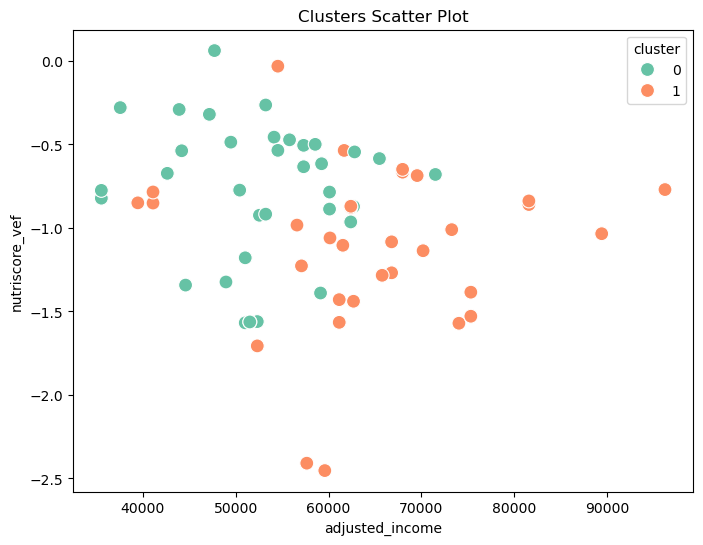

In [236]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='adjusted_income',
    y='nutriscore_vef',
    hue='cluster',        # color by cluster
    palette='Set2',       # choose a color palette
    data=df_2,
    s=100                 # size of points
)
plt.title('Clusters Scatter Plot')
plt.show()

In [240]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Example dataset
data = df_2

df = pd.DataFrame(data)

# Features (independent variables)
X = df[['unique_veg','unique_fruit','nutriscore_vef','nutriscore_entree','unique_entree']]

# Target (dependent variable)
y = df['adjusted_income']

# Split data into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create linear regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Print coefficients
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R^2 Score:", r2)


Intercept: 46037.468042532906
Coefficients: [  -29.99847268   115.56766511 -2673.92090257   317.53866959
   199.07148468]
Mean Squared Error: 69917056.04959463
R^2 Score: 0.20708835566061146


In [246]:
import pandas as pd
import statsmodels.api as sm


# Select features and target
X = df[['unique_veg', 'unique_fruit', 'nutriscore_vef', 'nutriscore_entree', 'unique_entree']]
y = df['adjusted_income']

# Add intercept (constant)
X = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X).fit()

# View summary with coefficients, p-values, R-squared, etc.
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        adjusted_income   R-squared:                       0.111
Model:                            OLS   Adj. R-squared:                  0.041
Method:                 Least Squares   F-statistic:                     1.592
Date:                Mon, 06 Apr 2026   Prob (F-statistic):              0.175
Time:                        01:08:57   Log-Likelihood:                -751.74
No. Observations:                  70   AIC:                             1515.
Df Residuals:                      64   BIC:                             1529.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              4.559e+04   8658.60

In [249]:
df[['unique_veg', 'unique_fruit', 'nutriscore_vef', 'nutriscore_entree', 'unique_entree','adjusted_income']].corr()

,unique_veg,unique_fruit,nutriscore_vef,nutriscore_entree,unique_entree,adjusted_income
unique_veg,1.000000,0.003855,-0.229114,0.270887,0.363235,0.100074
unique_fruit,0.003855,1.000000,0.208153,-0.130261,-0.031047,0.019324
nutriscore_vef,-0.229114,0.208153,1.000000,0.426162,-0.168584,-0.175291
nutriscore_entree,0.270887,-0.130261,0.426162,1.000000,0.339791,0.035062
unique_entree,0.363235,-0.031047,-0.168584,0.339791,1.000000,0.299214
adjusted_income,0.100074,0.019324,-0.175291,0.035062,0.299214,1.000000


In [254]:
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# Features and target
X = df[['unique_veg', 'unique_fruit', 'nutriscore_vef', 'unique_entree']]
y = df['adjusted_income']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame (important for statsmodels)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Add constant
X_scaled = sm.add_constant(X_scaled)

# Fit model
model = sm.OLS(y, X_scaled).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        adjusted_income   R-squared:                       0.110
Model:                            OLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     2.009
Date:                Mon, 06 Apr 2026   Prob (F-statistic):              0.104
Time:                        01:11:19   Log-Likelihood:                -751.76
No. Observations:                  70   AIC:                             1514.
Df Residuals:                      65   BIC:                             1525.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            5.84e+04   1384.875     42.

In [17]:
schools['average_unique'] = schools[['unique_veg', 'unique_fruit', 'unique_entree']].mean(axis=1)

In [92]:
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
import numpy as np

# Target (should be 1D for statsmodels)
y = merged_df['average_unique']

# Feature as DataFrame (keeps column name!)
X = np.log(merged_df[['adjusted_income']])


# Add constant
X = sm.add_constant(X)

# Fit model
model = sm.OLS(y, X_scaled).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         average_unique   R-squared:                       0.081
Model:                            OLS   Adj. R-squared:                  0.071
Method:                 Least Squares   F-statistic:                     7.880
Date:                Mon, 06 Apr 2026   Prob (F-statistic):            0.00614
Time:                        23:19:17   Log-Likelihood:                -315.63
No. Observations:                  91   AIC:                             635.3
Df Residuals:                      89   BIC:                             640.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         27.0000      0.823     32.808      0.0

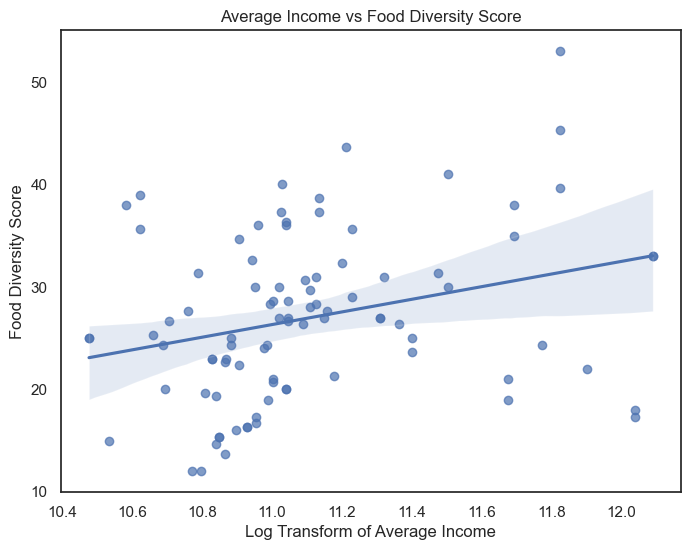

In [99]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

# Reshape data for Scikit-learn (requires 2D array for X)
y = merged_df[['average_unique']]
X = np.log(merged_df['adjusted_income']).to_numpy().reshape(-1, 1)

# Train model
model = LinearRegression().fit(X, y)
y_pred = model.predict(X)


# Plot
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Optional: nicer style like your first plot


plt.figure(figsize=(8, 6))
sns.set_style("white")
sns.regplot(
    x=np.log(merged_df['adjusted_income']),  # log scale like your second plot
    y=merged_df['average_unique'],
    scatter_kws={'alpha': 0.7},
    
)

plt.title('Average Income vs Food Diversity Score')
plt.xlabel('Log Transform of Average Income')
plt.ylabel('Food Diversity Score')
plt.grid(False)
plt.show()


In [ ]:
plt.scatter(X, y, label='Actual data')
plt.plot(X, y_pred, color='green', label='Regression line')

plt.legend()
plt.show()



In [21]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# Define variables
X = np.log(schools['adjusted_income']).to_numpy().reshape(-1, 1)
y = schools[['nutriscore_vef']]

# Add constant (intercept)
X = sm.add_constant(X)

# Fit regression model
model = sm.OLS(y, X).fit()

# Print full summary (optional)
print(model.summary())

# Extract key values
intercept = model.params['const']
slope = model.params['x1']
r_squared = model.rsquared
p_value = model.pvalues['x1']

print("\n--- Key Results ---")
print(f"Intercept (Nutrition Score): {intercept}")
print(f"Slope (Average Income): {slope}")
print(f"R-squared: {r_squared}")
print(f"P-value: {p_value}")

                            OLS Regression Results                            
Dep. Variable:         nutriscore_vef   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.9183
Date:                Wed, 08 Apr 2026   Prob (F-statistic):              0.341
Time:                        13:59:42   Log-Likelihood:                -64.214
No. Observations:                  91   AIC:                             132.4
Df Residuals:                      89   BIC:                             137.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5358      1.544      0.347      0.7

/var/folders/hh/1ddz0cz536sb8pznv3jdpz180000gn/T/ipykernel_55150/3804331210.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


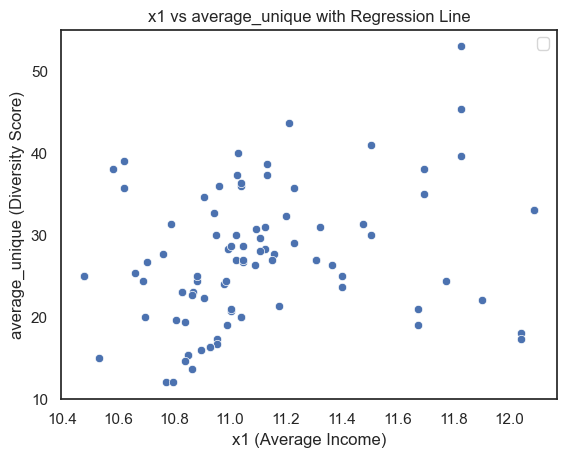

In [123]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

x_sorted = np.sort(X)                      # sort predictor
X_sorted = sm.add_constant(x_sorted)       # add intercept
y_pred = model.predict(X_sorted)           # predicted values


sns.scatterplot(x=np.log(merged_df['adjusted_income']).to_numpy(), y=merged_df['average_unique'])

plt.xlabel("x1 (Average Income)")
plt.ylabel("average_unique (Diversity Score)")
plt.title("x1 vs average_unique with Regression Line")
plt.legend()
plt.show()


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract your predictor and response as 1D arrays
x = np.log(merged_df['adjusted_income']).to_numpy()  # 1D array
y = merged_df['average_unique'].to_numpy()           # 1D array

# 2. Fit the model (already done)
X = sm.add_constant(x)  # for intercept
model = sm.OLS(y, X).fit()

# 3. Create sorted x-values for a smooth regression line
x_sorted = np.sort(x)                      # sort predictor
X_sorted = sm.add_constant(x_sorted)       # add intercept
y_pred = model.predict(X_sorted)           # predicted values

# 4. Plot scatter points
sns.scatterplot(x=x, y=y, alpha=0.6)

# 5. Plot regression line
plt.plot(x_sorted, y_pred)

plt.xlabel("Log Transfor of Average Income")
plt.ylabel("Diversity Score")
plt.title("Average Income vs Diversity Score")
plt.legend()
plt.show()

KeyError: 'adjusted_income'

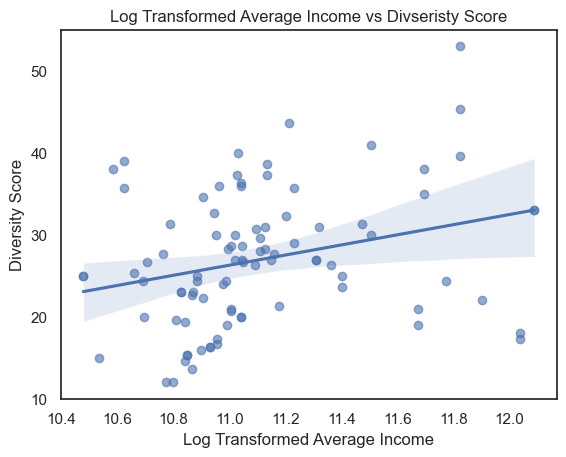

In [128]:
sns.regplot(
    
    x=np.log(merged_df['adjusted_income']).to_numpy(),
    y=merged_df['nutriscore_vef'].to_numpy(),
    scatter_kws={'alpha': 0.6}
)

plt.xlabel('Log Transformed Average Income')
plt.ylabel('Diversity Score')
plt.title('Log Transformed Average Income vs Divseristy Score')
plt.show()

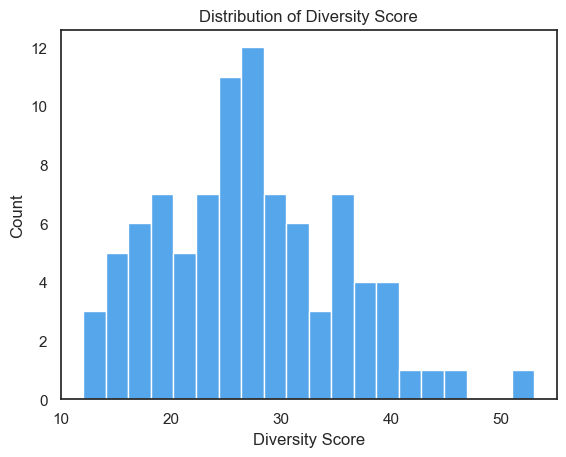

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histogram
sns.histplot(merged_df['average_unique'], bins=20, kde=False, color='#1E88E5')

plt.xlabel("Diversity Score")
plt.ylabel("Count")
plt.title("Distribution of Diversity Score")
plt.show()

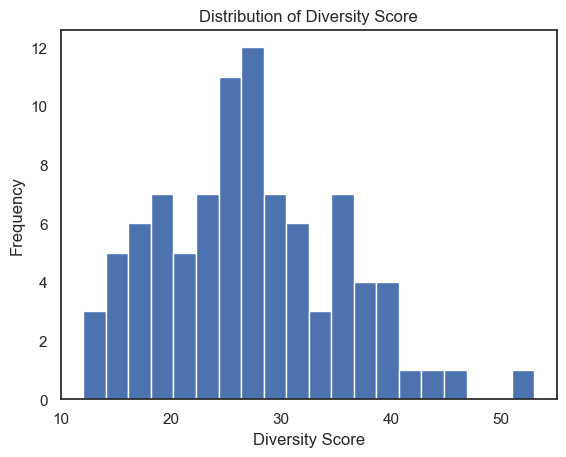

In [142]:
import matplotlib.pyplot as plt

plt.figure()

plt.hist(merged_df['average_unique'], bins=20)
plt.title('Distribution of Diversity Score')
plt.xlabel('Diversity Score')
plt.ylabel('Frequency')

plt.show()

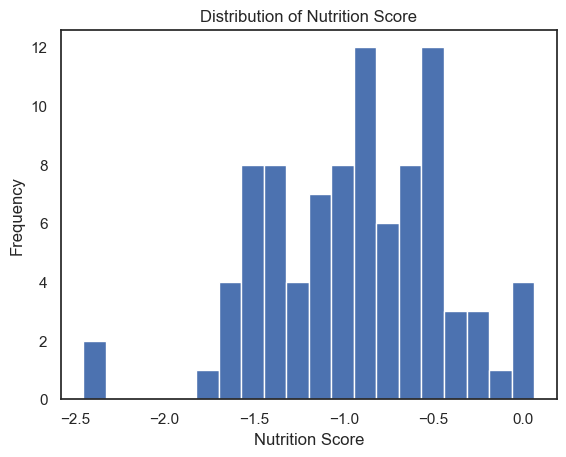

In [146]:
import matplotlib.pyplot as plt

plt.figure()

plt.hist(merged_df['nutriscore_vef'], bins=20)
plt.title('Distribution of Nutrition Score')
plt.xlabel('Nutrition Score')
plt.ylabel('Frequency')

plt.show()

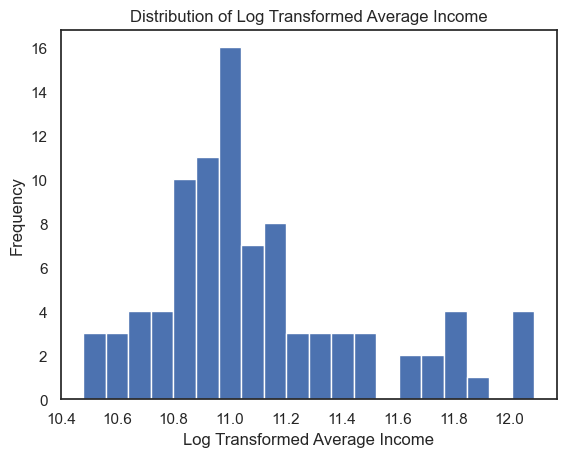

In [145]:
import matplotlib.pyplot as plt

plt.figure()

plt.hist(np.log(merged_df['adjusted_income']).to_numpy(), bins=20)
plt.title('Distribution of Log Transformed Average Income')
plt.xlabel('Log Transformed Average Income')
plt.ylabel('Frequency')

plt.show()

/var/folders/hh/1ddz0cz536sb8pznv3jdpz180000gn/T/ipykernel_55150/2051641876.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


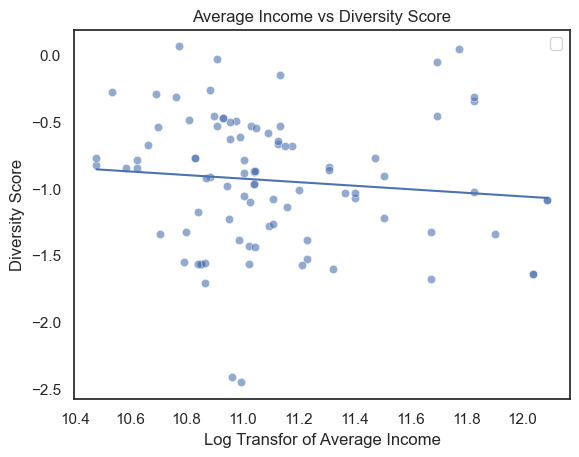

In [147]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract your predictor and response as 1D arrays
x = np.log(merged_df['adjusted_income']).to_numpy()  # 1D array
y = merged_df['nutriscore_vef'].to_numpy()           # 1D array

# 2. Fit the model (already done)
X = sm.add_constant(x)  # for intercept
model = sm.OLS(y, X).fit()

# 3. Create sorted x-values for a smooth regression line
x_sorted = np.sort(x)                      # sort predictor
X_sorted = sm.add_constant(x_sorted)       # add intercept
y_pred = model.predict(X_sorted)           # predicted values

# 4. Plot scatter points
sns.scatterplot(x=x, y=y, alpha=0.6)

# 5. Plot regression line
plt.plot(x_sorted, y_pred)

plt.xlabel("Log Transfor of Average Income")
plt.ylabel("Diversity Score")
plt.title("Average Income vs Diversity Score")
plt.legend()
plt.show()

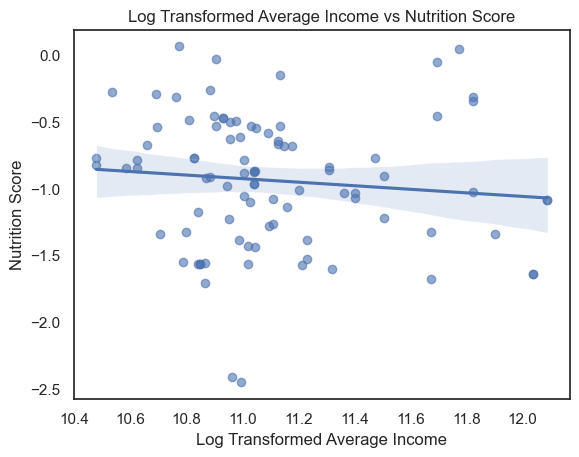

In [150]:
sns.regplot(
    
    x=np.log(merged_df['adjusted_income']).to_numpy(),
    y=merged_df['nutriscore_vef'].to_numpy(),
    scatter_kws={'alpha': 0.6}
)

plt.xlabel('Log Transformed Average Income')
plt.ylabel('Nutrition Score')
plt.title('Log Transformed Average Income vs Nutrition Score')
plt.show()

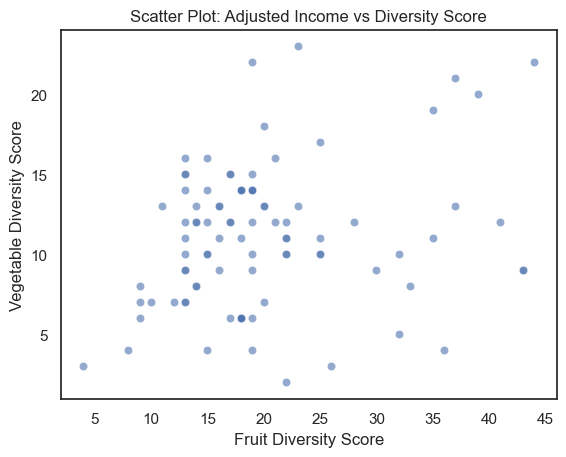

In [163]:
import seaborn as sns
import matplotlib.pyplot as plt

# x = predictor, y = response
x = merged_df['unique_veg']       # your X variable
y = merged_df['unique_fruit']        # your Y variable

# Scatter plot
sns.scatterplot(x=x, y=y, alpha=0.6)

plt.xlabel("Vegetable Diversity Score")
plt.ylabel("Fruit Diversity Score")
plt.title("Vegetable vs Fruit Diversity Score with Line of Best Fit")
plt.show()

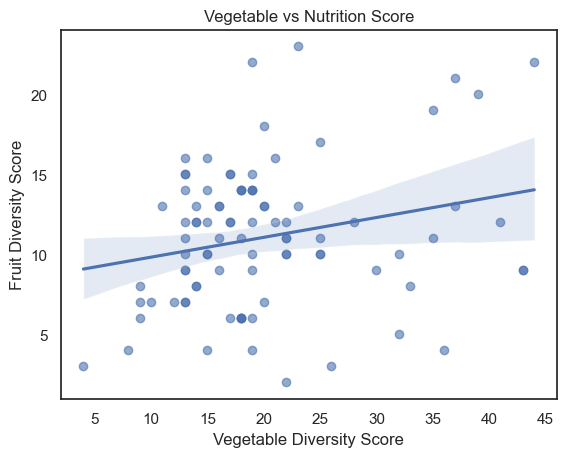

In [192]:
sns.regplot(
    
    x=merged_df['unique_veg'].to_numpy(),
    y=merged_df['unique_fruit'].to_numpy(),
    scatter_kws={'alpha': 0.6}
)

plt.xlabel('Vegetable Diversity Score')
plt.ylabel('Fruit Diversity Score')
plt.title('Vegetable vs Nutrition Score')
plt.show()

In [183]:
import pandas as pd
import statsmodels.api as sm

# Define variables
X = merged_df['unique_veg']
y = merged_df['unique_fruit']

# Add constant (intercept)
X = sm.add_constant(X)

# Fit regression model
model = sm.OLS(y, X).fit()

# Print full summary (optional)
print(model.summary())

# Extract key values
intercept = model.params['const']
slope = model.params['unique_veg']
r_squared = model.rsquared
p_value = model.pvalues['unique_veg']

print("\n--- Key Results ---")
print(f"Intercept (Fruit Diversity Score): {intercept}")
print(f"Slope (Vegetable Diversity Score): {slope}")
print(f"R-squared: {r_squared}")
print(f"P-value: {p_value}")

                            OLS Regression Results                            
Dep. Variable:           unique_fruit   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     5.357
Date:                Tue, 07 Apr 2026   Prob (F-statistic):             0.0229
Time:                        00:28:54   Log-Likelihood:                -261.51
No. Observations:                  91   AIC:                             527.0
Df Residuals:                      89   BIC:                             532.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.5867      1.168      7.353      0.0

In [195]:
import pandas as pd
import statsmodels.api as sm

# Define variables
X = merged_df['nutriscore_entree']
y = merged_df['unique_veg']

# Add constant (intercept)
X = sm.add_constant(X)

# Fit regression model
model = sm.OLS(y, X).fit()

# Print full summary (optional)
print(model.summary())

# Extract key values
intercept = model.params['const']
slope = model.params['nutriscore_entree']
r_squared = model.rsquared
p_value = model.pvalues['nutriscore_entree']

print("\n--- Key Results ---")
print(f"Intercept (Vegetable Diversity Score): {intercept}")
print(f"Slope (Entree Nutrition Score): {slope}")
print(f"R-squared: {r_squared}")
print(f"P-value: {p_value}")

                            OLS Regression Results                            
Dep. Variable:             unique_veg   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.138
Method:                 Least Squares   F-statistic:                     15.38
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           0.000172
Time:                        00:38:00   Log-Likelihood:                -316.43
No. Observations:                  91   AIC:                             636.9
Df Residuals:                      89   BIC:                             641.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                28.2107      2.22

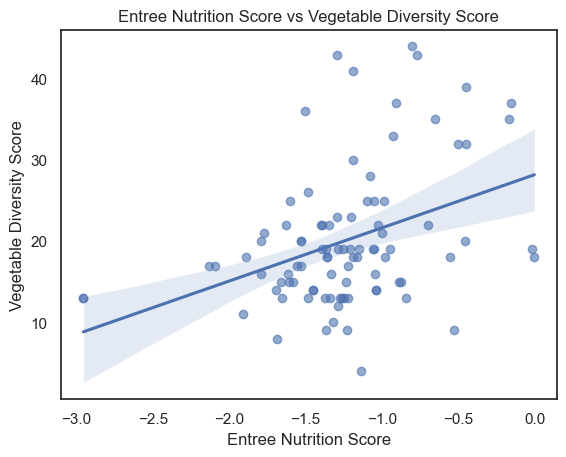

In [194]:
sns.regplot(
    
    x=merged_df['nutriscore_entree'].to_numpy(),
    y=merged_df['unique_veg'].to_numpy(),
    scatter_kws={'alpha': 0.6}
)

plt.xlabel('Entree Nutrition Score')
plt.ylabel('Vegetable Diversity Score')
plt.title('Entree Nutrition Score vs Vegetable Diversity Score')
plt.show()

/var/folders/hh/1ddz0cz536sb8pznv3jdpz180000gn/T/ipykernel_38869/1607430597.py:6: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  school_menus_df = pd.read_csv('School_Menus.csv')


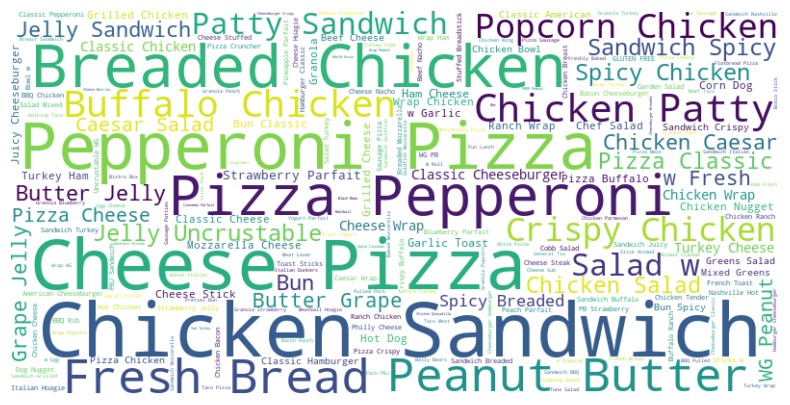

In [7]:
# 1. Load data
import pandas as pd
from wordcloud import WordCloud,  STOPWORDS
import matplotlib.pyplot as plt

school_menus_df = pd.read_csv('School_Menus.csv')

# 2. Filter only entrees and join text
text = " ".join(
    review for review in school_menus_df[school_menus_df['category'] == 'entree']['food_name']
    if isinstance(review, str)
)

# 3. Create WordCloud object
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=STOPWORDS
).generate(text)

# 4. Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")  # Hide axes
plt.show()

In [208]:
school_menus_df[school_menus_df['category'] == 'entree']['food_name']

AttributeError: Can only use the '.list' accessor with 'list[pyarrow]' dtype, not object.

/var/folders/hh/1ddz0cz536sb8pznv3jdpz180000gn/T/ipykernel_38869/3604274286.py:5: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  school_menus_df = pd.read_csv('School_Menus.csv')


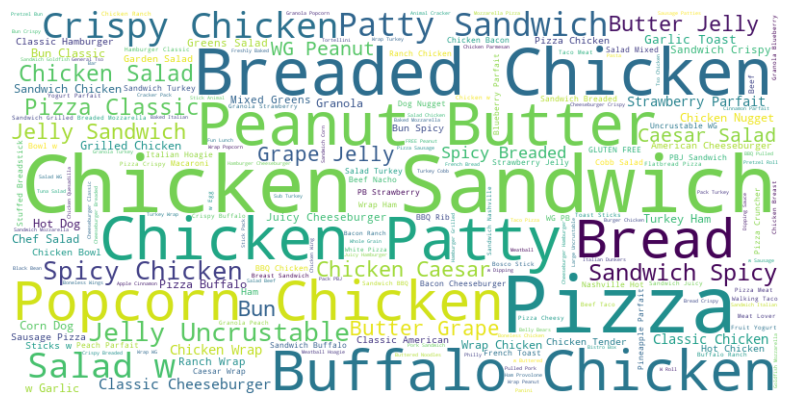

In [8]:
import pandas as pd
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
# 1. Load data
school_menus_df = pd.read_csv('School_Menus.csv')



# 2. Filter only entrees and join text
text = " ".join(
    review for review in school_menus_df[school_menus_df['category'] == 'entree']['food_name']
    if isinstance(review, str)
)



# 3. Create WordCloud object
wordcloud = WordCloud(
   
    width=800,
    height=400,
    background_color='white',
    stopwords=STOPWORDS.update(['diced','fresh','delicious','sliced','slices','steamed','seasoned','florets','cheese','pepperoni'])
).generate(text)

# 4. Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")  # Hide axes
plt.show()

/var/folders/hh/1ddz0cz536sb8pznv3jdpz180000gn/T/ipykernel_38869/2784877069.py:5: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  school_menus_df = pd.read_csv('School_Menus.csv')


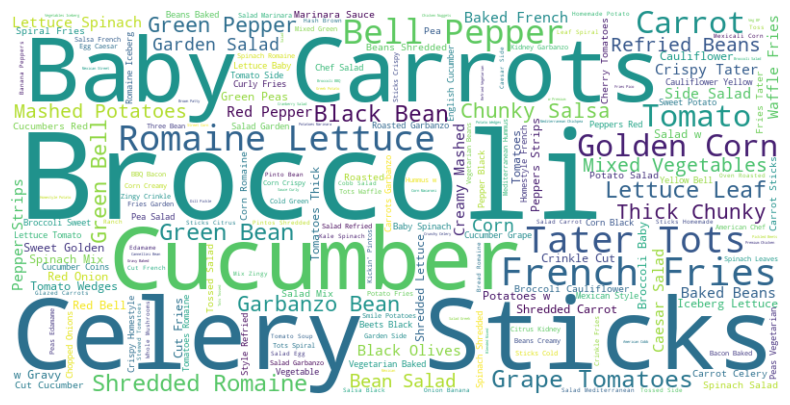

In [9]:
import pandas as pd
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
# 1. Load data
school_menus_df = pd.read_csv('School_Menus.csv')



# 2. Filter only entrees and join text
text = " ".join(
    review for review in school_menus_df[school_menus_df['category'] == 'vegetable']['food_name']
    if isinstance(review, str)
)



# 3. Create WordCloud object
wordcloud = WordCloud(
   
    width=800,
    height=400,
    background_color='white',
    stopwords=STOPWORDS.update(['diced','fresh','delicious','sliced','slices','steamed','seasoned','florets','cheese','pepperoni'])
).generate(text)

# 4. Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")  # Hide axes
plt.show()

/var/folders/hh/1ddz0cz536sb8pznv3jdpz180000gn/T/ipykernel_38869/2458611219.py:5: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  school_menus_df = pd.read_csv('School_Menus.csv')


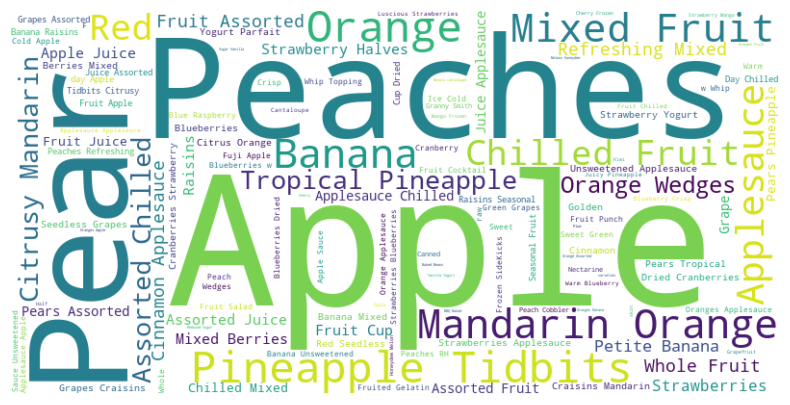

In [10]:
import pandas as pd
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
# 1. Load data
school_menus_df = pd.read_csv('School_Menus.csv')



# 2. Filter only entrees and join text
text = " ".join(
    review for review in school_menus_df[school_menus_df['category'] == 'fruit']['food_name']
    if isinstance(review, str)
)



# 3. Create WordCloud object
wordcloud = WordCloud(
   
    width=800,
    height=400,
    background_color='white',
    stopwords=STOPWORDS.update(['diced','fresh','delicious','sliced','slices','steamed','seasoned','florets','cheese','pepperoni'])
).generate(text)

# 4. Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")  # Hide axes
plt.show()

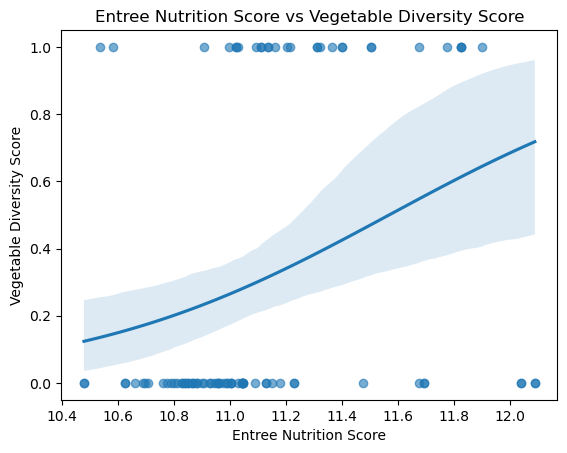

In [125]:
import seaborn as sns
import numpy as np



sns.regplot(
    
x=np.log(schools['adjusted_income']).to_numpy(),
y = schools['school_in_list'].to_numpy(),
scatter_kws={'alpha': 0.6},
logistic=True, 
)

plt.xlabel('Entree Nutrition Score')
plt.ylabel('Vegetable Diversity Score')
plt.title('Entree Nutrition Score vs Vegetable Diversity Score')
plt.show()

In [122]:
schools = pd.read_csv('income_and_scores.csv')

In [121]:
np.log(schools['Adjusted\nPersonal\nIncome\nJune 2025']).tonumpy

AttributeError: 'Series' object has no attribute 'tonumpy'

In [123]:
schools['school_in_list'] = schools['school_name'].isin(unique_schools).astype(int)

In [11]:
schools = pd.read_csv('income_and_scores.csv')

In [12]:
schools

,Unnamed: 0,school_name,unique_veg,unique_fruit,nutriscore_entree,nutriscore_vef,unique_entree,district,County,Records,Adjusted\nPersonal\nIncome\nJune 2025,adjusted_income
0,0,Beaver Area High - Beaver Area School District...,22,11,-1.350340,-0.838983,48,Beaver Area,Beaver,7376.0,6.017820e+08,81586.492001
1,1,Beaver Area Middle - Beaver Area School Distri...,22,11,-1.390244,-0.860399,48,Beaver Area,Beaver,7376.0,6.017820e+08,81586.492001
2,2,Bedford Area High School - Bedford Area School...,16,13,-1.794118,-0.887640,33,Bedford Area,Bedford,7695.0,4.625234e+08,60106.998311
3,3,Bedford Area Middle School - Bedford Area Scho...,16,11,-1.618182,-0.785714,36,Bedford Area,Bedford,7695.0,4.625234e+08,60106.998311
4,4,Bellwood-Antis High School - Bellwood-Antis Sc...,18,14,-1.357143,-0.964706,28,Bellwood-Antis,Blair,3867.0,2.412723e+08,62392.621929
...,...,...,...,...,...,...,...,...,...,...,...,...
86,86,Windber Area High School - Windber Area School...,4,3,-1.137931,-1.324324,29,Windber Area,Somerset,4014.0,1.964786e+08,48948.336821
87,87,Wissahickon High - Wissahickon School District...,14,12,-1.448819,-1.087719,73,Wissahickon,Montgomery,20203.0,3.593866e+09,177887.735287
88,88,Wissahickon Middle - Wissahickon School Distri...,14,12,-1.448819,-1.087719,73,Wissahickon,Montgomery,20203.0,3.593866e+09,177887.735287
89,89,Yough High School - Yough School District - PA,19,14,-1.257143,-0.872340,48,Yough,Westmoreland,7178.0,4.499834e+08,62689.249652
